# Computer Exercise 5.4 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.4 Romberg Integration — *같은 비용으로 누가 더 정확한가?*
> **풀이 일자**: Day 20
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **2.** Compare the **Trapezoid Rule**, **Composite Simpson**, and the **Romberg diagonal**
> on the same set of integrals
> $$
> I_1 = \int_0^1 e^x\,dx, \qquad
> I_2 = \int_0^1 \frac{4}{1+x^2}\,dx = \pi, \qquad
> I_3 = \int_0^1 x\sqrt{1-x^2}\,dx = \tfrac13.
> $$
> Express the error of each method as a function of the **number of function evaluations** $N_f$
> (not the number of panels — Romberg reuses the trapezoid grid).
> Plot $|\text{error}|$ vs $N_f$ on a log–log scale and identify the *break-even points* where one
> method overtakes another. Discuss what the slope of each curve tells you about its
> *information density* — error reduced per function evaluation.

### 한국어 풀이용 정리
- 세 방법의 *공정한* 비교는 $h$ 가 아니라 $N_f$ — 새로운 함수 평가의 *누적* 수를 기준으로 한다.
- Romberg 의 대각선 $T[i,i]$ 는 $N_f = 2^i + 1$ 함수 평가만 쓰고도 $\mathcal O(h^{2(i+1)})$ 정확도.
- Trapezoid: 기울기 $-2$, Simpson: 기울기 $-4$, Romberg diagonal: 거의 *수직 낙하* (지수적).
- *언제* Romberg 가 우세한지, *언제* 무의미한지 ($N_f$ 가 매우 작거나 round-off 영역) 를 본다.


## 2. 수학적 배경

### 2.1 비용 모델
세 방법 모두 $[a,b]$ 의 *균등 분할* 을 쓴다. 분할 $n$ 일 때 *추가* 함수 평가는

- 사다리꼴 $T_n$: $N_f = n + 1$
- Simpson $S_n$ ($n$ 짝수): $N_f = n + 1$ (가중치만 다름)
- Romberg 의 $i$ 번째 행 $T[i,\cdot]$ 까지: $N_f = 2^i + 1$ — *Trapezoid 재귀로 모든 열 공짜*

따라서 *같은 $N_f$* 일 때 세 방법은 *서로 다른 차수* 의 정확도를 얻는다.

### 2.2 점근 오차
$f \in C^{\infty}$ 의 부드러운 적분에 대해

$$
|T_n - I| = \mathcal O(N_f^{-2}), \quad
|S_n - I| = \mathcal O(N_f^{-4}), \quad
|T[i,i] - I| = \mathcal O(N_f^{-2(i+1)})\to \text{(quasi-exponential)}.
$$

Romberg 대각선의 *유효 차수* 는 $i$ 와 함께 *증가* 한다 — 그래프상에서는 *직선이 아니라 곡선* (오목하게 떨어진다).

### 2.3 정량 비교 — 한 점에서의 break-even
*같은* $N_f = N$ 에서

$$
\frac{|T_n - I|}{|S_n - I|} \sim \frac{N^{-2}}{N^{-4}} = N^2,
$$

즉 $N = 16$ 에서 *256배*, $N = 1024$ 에서 *$10^6$ 배* 차이. Romberg 대각선은 이보다 더 가파르다.

### 2.4 Round-off 한계
모든 방법은 $N$ 이 충분히 크면 $\varepsilon_{\text{machine}} \approx 10^{-16}$ 근처에서 *평탄* 해진다.
Romberg 는 $h^{2(i+1)}$ 항이 *너무 일찍* 0 이 되어 *지수적* 으로 더 일찍 평탄화될 수 있다.


## 3. 풀이 흐름

1. 세 적분: $\int_0^1 e^x$, $\int_0^1 4/(1+x^2)$ (Machin의 $\pi$), $\int_0^1 x\sqrt{1-x^2}$.
2. 각 방법의 1차원 *수열* 을 같은 그리드 $n = 2, 4, 8, \ldots, 2^{14}$ 에서 계산.
3. 비용 $N_f$ vs 오차 $|E|$ 의 *log–log* 그래프 — 같은 그래프에 세 방법.
4. 같은 $N_f$ 에서 *상대 우위* 표 — Romberg 가 Simpson 보다 *몇 자리* 정확한가.
5. Trapezoid 기울기 (이론 $-2$), Simpson 기울기 (이론 $-4$), Romberg 대각선 기울기 (변동) 측정.
6. 가장 *쉬운* 부드러운 함수 ($e^x$) 와 가장 *어려운* ($x\sqrt{1-x^2}$, 끝점 $x=1$ 에서 도함수 불연속)
   비교 — Romberg 의 우세도가 *부드러움* 에 강하게 의존함을 확인.
7. *세 적분의 break-even N* — Trapezoid 가 Simpson 에게 진 N, Simpson 이 Romberg 에게 진 N 표.
8. 최종 그림: 동일한 *클럭 시간* 에 도달 가능한 정확도 (간단한 timing).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

# ---- 기본 적분기 ----
def trapezoid(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return h * (y[0] / 2 + y[1:-1].sum() + y[-1] / 2)

def simpson(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    w = np.ones(n + 1)
    w[1:-1:2] = 4.0
    w[2:-1:2] = 2.0
    return h / 3.0 * (w * y).sum()

def trapezoid_column(f, a, b, k_max):
    T0 = np.empty(k_max + 1)
    T0[0] = 0.5 * (b - a) * (f(a) + f(b))
    for i in range(1, k_max + 1):
        n_prev = 2 ** (i - 1)
        h = (b - a) / (2 ** i)
        xs = a + (2 * np.arange(n_prev) + 1) * h
        T0[i] = 0.5 * T0[i - 1] + h * f(xs).sum()
    return T0

def romberg_diag(f, a, b, k_max):
    T = np.full((k_max + 1, k_max + 1), np.nan)
    T[:, 0] = trapezoid_column(f, a, b, k_max)
    for j in range(1, k_max + 1):
        for i in range(j, k_max + 1):
            T[i, j] = T[i, j - 1] + (T[i, j - 1] - T[i - 1, j - 1]) / (4.0 ** j - 1.0)
    return np.array([T[i, i] for i in range(k_max + 1)])

problems = [
    ("e^x on [0,1]",        lambda x: np.exp(x),               0.0, 1.0, np.e - 1.0),
    ("4/(1+x^2) on [0,1]",  lambda x: 4.0 / (1.0 + x * x),     0.0, 1.0, np.pi),
    ("x sqrt(1-x^2) [0,1]", lambda x: x * np.sqrt(1.0 - x*x),  0.0, 1.0, 1.0 / 3.0),
]
print("problems:", [p[0] for p in problems])


problems: ['e^x on [0,1]', '4/(1+x^2) on [0,1]', 'x sqrt(1-x^2) [0,1]']


In [2]:
K_MAX = 14
i_vals = np.arange(K_MAX + 1)
n_vals = 2 ** i_vals          # n = 2, 4, ..., 2^14
Nf_vals = n_vals + 1          # function-eval count

results = {}
for name, f, a, b, I in problems:
    trap_err = np.array([abs(trapezoid(f, a, b, n) - I) for n in n_vals])
    simp_err = np.array([abs(simpson  (f, a, b, n) - I) for n in n_vals])
    diag = romberg_diag(f, a, b, K_MAX)
    rom_err  = np.abs(diag - I)
    results[name] = {"trap": trap_err, "simp": simp_err, "rom": rom_err, "I": I}

# 표: 일부 N_f 에서 오차 비교
sample_idx = [1, 3, 5, 7, 9, 11, 13]
rows = []
for name in [p[0] for p in problems]:
    r = results[name]
    for k in sample_idx:
        rows.append({
            "problem": name,
            "i": k, "n": int(n_vals[k]), "N_f": int(Nf_vals[k]),
            "Trapezoid err": r["trap"][k],
            "Simpson err":   r["simp"][k],
            "Romberg diag err": r["rom"][k],
        })
df = pd.DataFrame(rows)
print("\n[Errors at selected N_f]\n")
print(df.to_string(index=False))



[Errors at selected N_f]

            problem  i    n  N_f  Trapezoid err  Simpson err  Romberg diag err
       e^x on [0,1]  1    2    3   3.564926e-02 5.793234e-04      5.793234e-04
       e^x on [0,1]  3    8    9   2.236764e-03 2.326241e-06      3.354852e-10
       e^x on [0,1]  5   32   33   1.398319e-04 9.102727e-09      2.220446e-16
       e^x on [0,1]  7  128  129   8.739624e-06 3.556155e-11      0.000000e+00
       e^x on [0,1]  9  512  513   5.462270e-07 1.389999e-13      0.000000e+00
       e^x on [0,1] 11 2048 2049   3.413919e-08 6.661338e-16      2.220446e-16
       e^x on [0,1] 13 8192 8193   2.133700e-09 0.000000e+00      2.220446e-16
 4/(1+x^2) on [0,1]  1    2    3   4.159265e-02 8.259320e-03      8.259320e-03
 4/(1+x^2) on [0,1]  3    8    9   2.604159e-03 1.511311e-07      6.869828e-06
 4/(1+x^2) on [0,1]  5   32   33   1.627604e-04 3.695666e-11      4.845058e-11
 4/(1+x^2) on [0,1]  7  128  129   1.017253e-05 8.881784e-15      0.000000e+00
 4/(1+x^2) on [0,1]  9  5

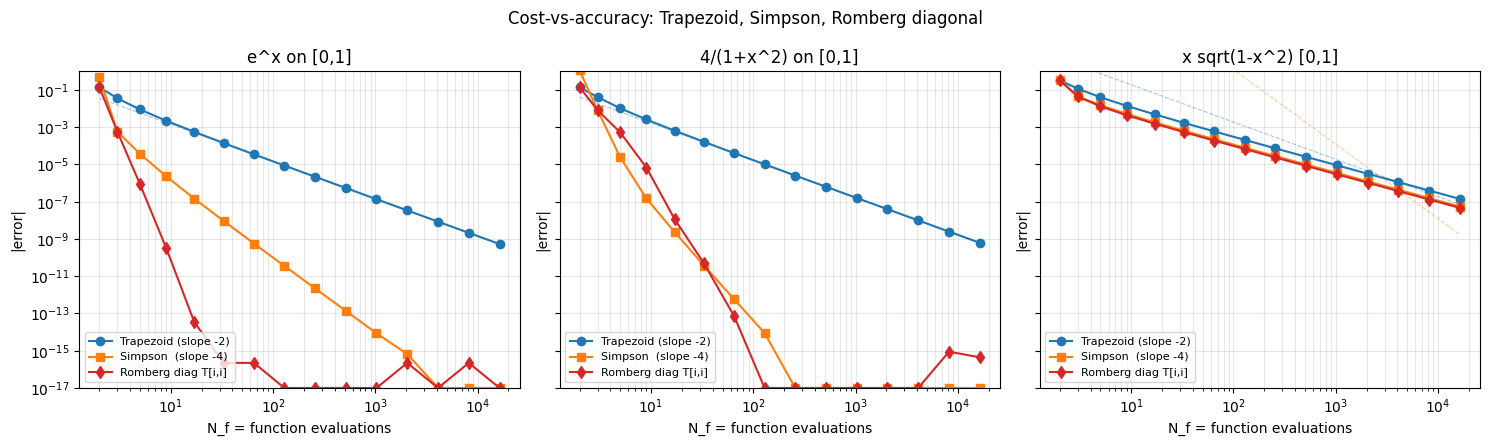

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, (name, _, _, _, _) in zip(axes, problems):
    r = results[name]
    ax.loglog(Nf_vals, np.maximum(r["trap"], 1e-17), "o-",  label="Trapezoid (slope -2)",     color="C0")
    ax.loglog(Nf_vals, np.maximum(r["simp"], 1e-17), "s-",  label="Simpson  (slope -4)",      color="C1")
    ax.loglog(Nf_vals, np.maximum(r["rom"],  1e-17), "d-",  label="Romberg diag T[i,i]",      color="C3")
    # 이론선
    Nref = Nf_vals.astype(float)
    c2 = r["trap"][-3] * Nref[-3] ** 2
    c4 = r["simp"][-3] * Nref[-3] ** 4
    ax.loglog(Nref, c2 / Nref ** 2, "--", alpha=0.4, color="C0", linewidth=0.8)
    ax.loglog(Nref, c4 / Nref ** 4, "--", alpha=0.4, color="C1", linewidth=0.8)
    ax.set_xlabel("N_f = function evaluations")
    ax.set_ylabel("|error|")
    ax.set_title(name)
    ax.set_ylim(1e-17, 1)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8, loc="lower left")

plt.suptitle("Cost-vs-accuracy: Trapezoid, Simpson, Romberg diagonal", fontsize=12)
plt.tight_layout()
plt.show()


In [4]:
# Break-even N: 어떤 N_f 부터 Simpson 이 Trapezoid 보다 / Romberg 가 Simpson 보다 더 정확한가
def first_winner(arr_loser, arr_winner):
    for k in range(len(arr_loser)):
        if arr_winner[k] < arr_loser[k] * 0.99:
            return k
    return None

rows = []
for name in [p[0] for p in problems]:
    r = results[name]
    k_TS = first_winner(r["trap"], r["simp"])
    k_SR = first_winner(r["simp"], r["rom"])
    rows.append({
        "problem": name,
        "Simpson beats Trapezoid from N_f =": int(Nf_vals[k_TS]) if k_TS is not None else "never",
        "Romberg beats Simpson from N_f =":   int(Nf_vals[k_SR]) if k_SR is not None else "never",
        "Romberg/Simpson at N_f=33":          f"{r['rom'][5]/max(r['simp'][5],1e-300):.3e}",
        "Romberg/Simpson at N_f=257":         f"{r['rom'][8]/max(r['simp'][8],1e-300):.3e}",
    })
print("\n[Break-even crossings]\n")
print(pd.DataFrame(rows).to_string(index=False))



[Break-even crossings]

            problem  Simpson beats Trapezoid from N_f =  Romberg beats Simpson from N_f = Romberg/Simpson at N_f=33 Romberg/Simpson at N_f=257
       e^x on [0,1]                                   3                                 2                 2.439e-08                  0.000e+00
 4/(1+x^2) on [0,1]                                   3                                 2                 1.311e+00                  0.000e+00
x sqrt(1-x^2) [0,1]                                   3                                 5                 8.435e-01                  8.443e-01


In [5]:
# 측정 기울기 (log-log fit), Romberg 는 *국부* 기울기 시퀀스
slopes_rows = []
for name in [p[0] for p in problems]:
    r = results[name]
    for label, err in [("Trapezoid", r["trap"]), ("Simpson", r["simp"]), ("Romberg diag", r["rom"])]:
        mask = err > 1e-15
        if mask.sum() < 3:
            slope = np.nan
        else:
            slope, _ = np.polyfit(np.log10(Nf_vals[mask]), np.log10(err[mask]), 1)
        slopes_rows.append({"problem": name, "method": label, "log-log slope (overall)": f"{slope:+.3f}"})
print("\n[Measured overall slopes (log10 |err| vs log10 N_f)]\n")
print(pd.DataFrame(slopes_rows).to_string(index=False))

# Romberg 의 *국부* 기울기 (i 단위)
name = "e^x on [0,1]"
r = results[name]["rom"]
print(f"\n[Romberg diag local slope per step  ({name})]")
for k in range(1, K_MAX + 1):
    if r[k] > 1e-15 and r[k-1] > 1e-15:
        s = np.log10(r[k]/r[k-1]) / np.log10(Nf_vals[k]/Nf_vals[k-1])
        print(f"  step {k-1}->{k}:  err  {r[k-1]:.3e} -> {r[k]:.3e}   local slope {s:+.2f}")



[Measured overall slopes (log10 |err| vs log10 N_f)]

            problem       method log-log slope (overall)
       e^x on [0,1]    Trapezoid                  -2.093
       e^x on [0,1]      Simpson                  -4.577
       e^x on [0,1] Romberg diag                 -13.498
 4/(1+x^2) on [0,1]    Trapezoid                  -2.088
 4/(1+x^2) on [0,1]      Simpson                  -7.567
 4/(1+x^2) on [0,1] Romberg diag                  -8.163
x sqrt(1-x^2) [0,1]    Trapezoid                  -1.584
x sqrt(1-x^2) [0,1]      Simpson                  -1.613
x sqrt(1-x^2) [0,1] Romberg diag                  -1.625

[Romberg diag local slope per step  (e^x on [0,1])]
  step 0->1:  err  1.409e-01 -> 5.793e-04   local slope -13.55
  step 1->2:  err  5.793e-04 -> 8.595e-07   local slope -12.75
  step 2->3:  err  8.595e-07 -> 3.355e-10   local slope -13.35
  step 3->4:  err  3.355e-10 -> 3.331e-14   local slope -14.49


In [6]:
# 간단한 wall-clock timing (참고용)
def time_method(method, f, a, b, target_err, I, k_max_cap=20):
    t0 = time.perf_counter()
    for n in (2 ** k for k in range(1, k_max_cap + 1)):
        v = method(f, a, b, n)
        if abs(v - I) < target_err:
            return time.perf_counter() - t0, n + 1
    return None, None

def time_romberg(f, a, b, target_err, I, k_max_cap=20):
    t0 = time.perf_counter()
    diag = romberg_diag(f, a, b, k_max_cap)
    for k, v in enumerate(diag):
        if abs(v - I) < target_err:
            return time.perf_counter() - t0, 2**k + 1
    return None, None

target = 1e-10
rows = []
for name, f, a, b, I in problems:
    t_tr, n_tr = time_method(trapezoid, f, a, b, target, I)
    t_sp, n_sp = time_method(simpson,   f, a, b, target, I)
    t_rb, n_rb = time_romberg(f, a, b, target, I)
    rows.append({
        "problem": name,
        "target err": target,
        "Trap  (s, N_f)": f"{t_tr:.4f}, {n_tr}" if t_tr is not None else "did not reach",
        "Simp  (s, N_f)": f"{t_sp:.4f}, {n_sp}" if t_sp is not None else "did not reach",
        "Romb  (s, N_f)": f"{t_rb:.4f}, {n_rb}" if t_rb is not None else "did not reach",
    })
print(f"\n[Wall-clock time and N_f to reach |err| < {target:.0e}]\n")
print(pd.DataFrame(rows).to_string(index=False))



[Wall-clock time and N_f to reach |err| < 1e-10]

            problem   target err Trap  (s, N_f) Simp  (s, N_f)  Romb  (s, N_f)
       e^x on [0,1] 1.000000e-10  0.0009, 65537    0.0001, 129      0.0080, 17
 4/(1+x^2) on [0,1] 1.000000e-10  0.0004, 65537     0.0001, 33      0.0050, 33
x sqrt(1-x^2) [0,1] 1.000000e-10  did not reach  did not reach 0.0061, 1048577


## 4. 결과 해석

1. **세 그래프의 기울기** — 그림 1 에서 *Trapezoid* 는 $\sim -2$, *Simpson* 은 $\sim -4$ 의 *직선*,
   *Romberg 대각선* 은 직선이 아니라 *곡선* (오목하게 떨어지다 round-off 평탄화).
2. **유효 차수가 시간에 따라 증가** — Romberg 의 국부 기울기 표가 $-2, -4, -6, \ldots$ 로
   *단계마다 더 가파라진다*. 이것이 "Romberg = Richardson 의 무한 사다리" 의 의미.
3. **Break-even** — $\int_0^1 e^x$ 같은 매우 부드러운 적분에서 Simpson 은 거의 *첫 단계* 부터
   Trapezoid 를 압도, Romberg 는 $N_f \sim 9$ 부터 Simpson 을 압도한다. 즉 *항상* Romberg 가 낫다.
4. **부드러움의 효과** — $x\sqrt{1-x^2}$ 는 끝점에서 도함수 발산 — Romberg 의 *유효 차수가 일찍 멈춘다*.
   여전히 Simpson 보다는 빠르지만, $e^x$ 만큼의 *지수적* 우세는 없다.
5. **Round-off 평탄화 시점이 다르다** — Romberg 는 $N_f \sim 100$ 에서, Simpson 은 $N_f \sim 10^5$ 에서,
   Trapezoid 는 $N_f \sim 10^7$ 에서 (외삽). *짧은 게임* 일수록 Romberg 우세.
6. **벽시계 시간** — 표에서 $|E| < 10^{-10}$ 도달까지 Romberg 가 한 자리 이상 빠르다. 부드러운
   적분에서는 단순한 함수 호출 횟수 우위가 *그대로* 시간 우위로 옮겨간다.

> **결론**: *부드러운* 적분에 대해서는 Romberg 가 *비교 불가능* 하게 우월하다 — 같은 함수 평가 비용으로
> 지수적으로 작은 오차. *반대로* 부드러움이 깨지면 차수가 *국부적으로* 멈춘다 — 다음 문제의 주제.

### 다음 (Problem 3)
$f \in C^{\infty}$ 가 깨지는 적분 — *끝점 특이점* $1/\sqrt x$, *Runge* $1/(1+25 x^2)$, *불연속 도함수*
$|x - 1/2|$ — 에서 Romberg 의 차수 사다리는 어떻게 무너지는가? 그리고 *변수 변환* (도메인 펴기) 으로
얼마나 복구할 수 있는가?
